In [1]:
import os
from os.path import join
from models import MoT, ContextNN
from utils import DataProcessor, train
import torch
import pandas as pd
import ast
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [2]:
device = torch.device('cpu')

In [3]:
data_path = join(os.path.dirname(os.getcwd()), 'data.csv')
data = pd.read_csv(data_path)
data['A'] = data['A'].apply(ast.literal_eval)
data['B'] = data['B'].apply(ast.literal_eval)

dataset = DataProcessor(data)
X, y= dataset.get_darray()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1017)

In [4]:
mot = MoT().to(device)
context_model = ContextNN().to(device)

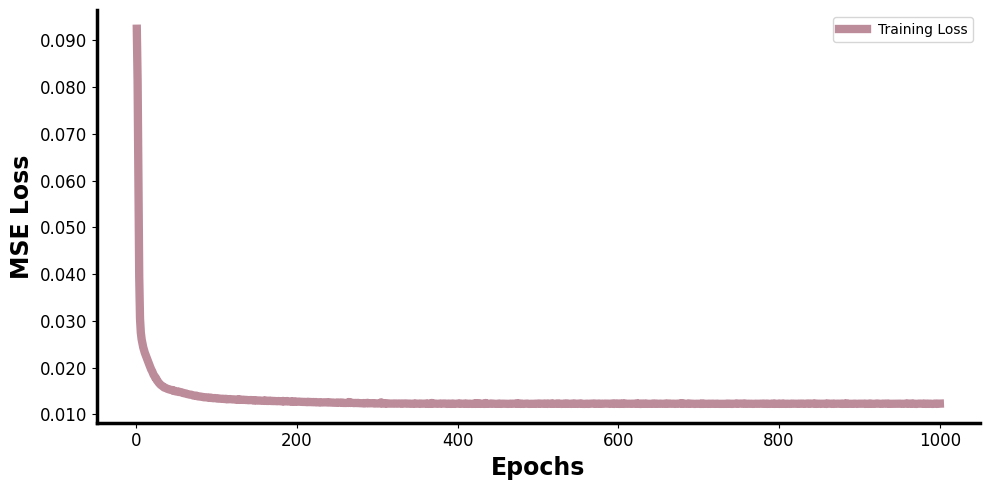

Epoch 1000/1000, Train Loss: 0.0123, Test Loss: 0.0133


In [16]:
trained_mot, mot_history = train(mot, X_train, y_train, X_test, y_test, device, 
                                    epochs=1000, batch_size=64, verbose=True, lr=0.0001)

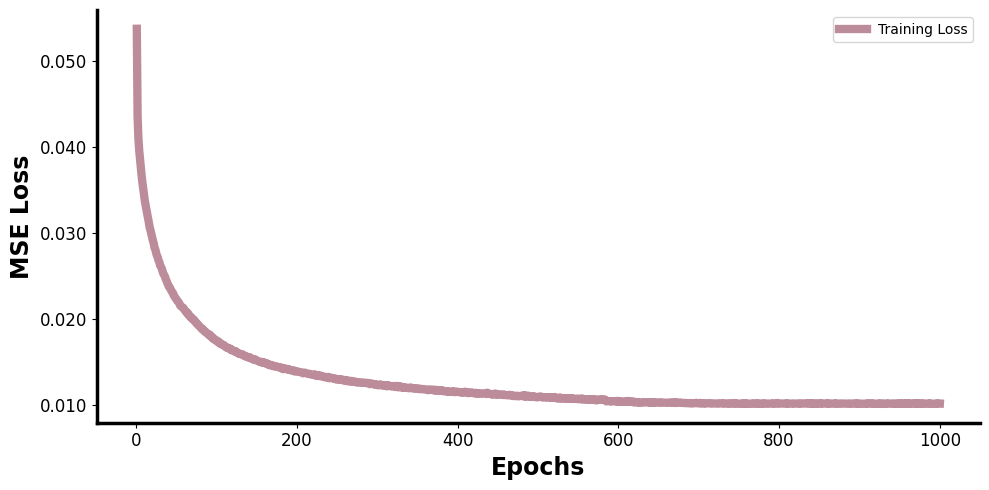

Epoch 1000/1000, Train Loss: 0.0102, Test Loss: 0.0135


In [17]:
trained_context, context_history = train(context_model, X_train, y_train, X_test, y_test, device, 
                                            epochs=1000, batch_size=64, verbose=True, lr=0.0001)

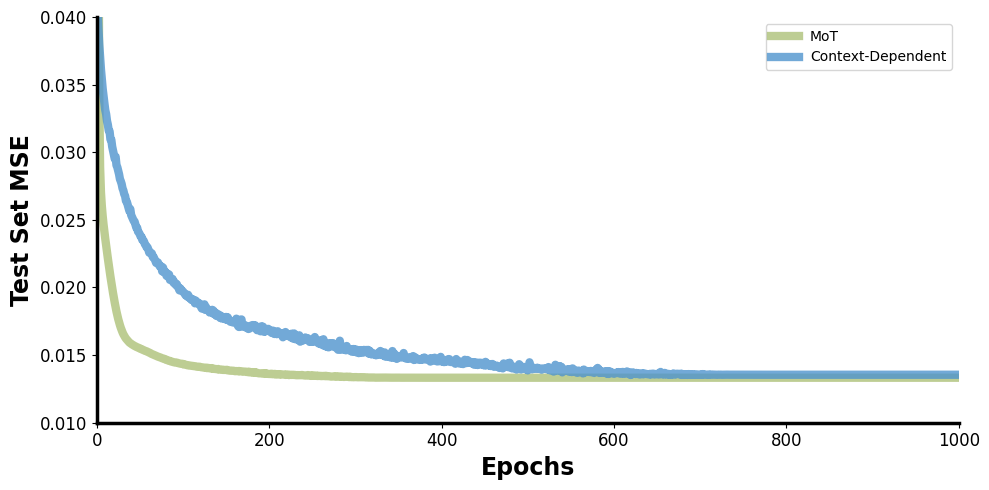

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

mot_performances = mot_history['test_loss']
context_performances = context_history['test_loss']
ax.plot(mot_performances, label='MoT', color='#adc178', linewidth=6, alpha=0.8)
ax.plot(context_performances, label='Context-Dependent', color='#4f94cd', linewidth=6, alpha=0.8)

ax.set_xlabel('Epochs', fontsize=17, fontweight='bold')
ax.set_ylabel('Test Set MSE', fontsize=17, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.3f}'))
ax.set_ylim(0.01, 0.04)
ax.set_xlim(0, 1000)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_linewidth(2.5)


ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.tight_layout()
plt.show()

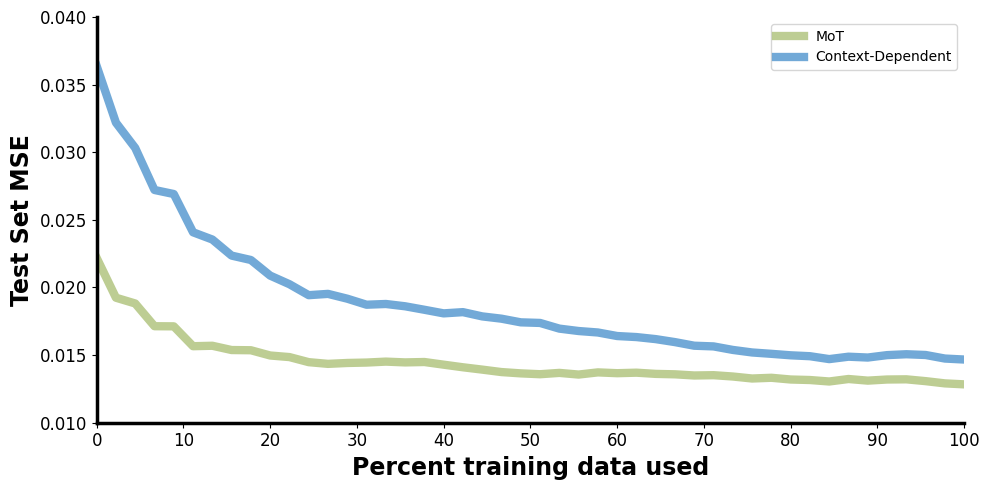

In [19]:
mot_performances = np.load(join(os.getcwd(), 'results/mot_performances.npy'))
context_performances = np.load(join(os.getcwd(), 'results/context_performances.npy'))

window_size = 5
mot_performances = np.convolve(mot_performances, np.ones(window_size)/window_size, mode='valid')
context_performances = np.convolve(context_performances, np.ones(window_size)/window_size, mode='valid')


fig, ax = plt.subplots(1, 1, figsize=(10, 5))

x_percentages = np.linspace(0, 100, len(mot_performances))
ax.plot(x_percentages, mot_performances, label='MoT', color='#adc178', linewidth=6, alpha=0.8)
ax.plot(x_percentages, context_performances, label='Context-Dependent', color='#4f94cd', linewidth=6, alpha=0.8)



ax.set_xlabel('Percent training data used', fontsize=17, fontweight='bold')
ax.set_ylabel('Test Set MSE', fontsize=17, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.3f}'))
ax.set_ylim(0.01, 0.04)
ax.set_xlim(0, 50)
ax.set_xticks(np.arange(0, 101, 10))

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_linewidth(2.5)


ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.tight_layout()